In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from utils.preprocess import add_indicators, train_test_split
from utils.ticker_data import windowed_dfs, custom_windowed_dfs
import os

In [3]:
def model_results(model, filename, data_path, save_path):
    df = pd.read_csv(data_path)
    if 'Date' in df:
        df['Date'] = pd.to_datetime(df.Date)
        df = df.set_index('Date')
    elif 'Datetime' in df:
        df['Datetime'] = pd.to_datetime(df.Datetime)
        df = df.set_index('Datetime')
        
    df_indicators = add_indicators(df)
    
    columns = ['Close', 'RSI10', 'MACD', 'EMA_10']
    target = 'Close'
    window_size = 30

    scaler = StandardScaler()
    for col in columns:
        df_indicators[col] = scaler.fit_transform(df_indicators[[col]])

    # X, y = windowed_dfs(df_indicators, columns=columns, target=target, train_window=window_size)
    X, y = custom_windowed_dfs(df_indicators, {'Close' : window_size}, target='Close')
    # X, y = custom_windowed_dfs(df_indicators, {'Close':window_size, 'RSI10':5, 'MACD':5, 'EMA_10':5, 'RSI10':5, 'MACD':5, 'EMA_10':5}, target='Close')

    X_train, y_train, X_test, y_test, test_dates = train_test_split(X, y, df.index, window_size=window_size)
    print(f"Train size : {len(X_train)}\tTest size : {len(X_test)}")
    
    print(f'Fitting {str(model)} on {filename}')
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    y_test = scaler.inverse_transform(y_test.reshape(-1,1))
    y_pred = scaler.inverse_transform(y_pred.reshape(-1,1))
    
    predict_df = pd.DataFrame({'actual': y_test.flatten(), 'predict': y_pred.flatten()})
    predict_df.to_csv(os.path.join(save_path, f'{filename}.csv'))
    
    print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)*100:.4f}%')
    plt.figure(figsize = (6, 4))
    plt.plot(y_pred, c = 'r', lw = 1, label = 'predicted')
    plt.plot(y_test, c='b', lw = 1, label = 'actual')

    plt.title(filename)
    plt.legend()
    
    os.makedirs(os.path.join(save_path, 'figures'), exist_ok=True)
    plt.savefig(os.path.join(save_path, 'figures', f'{filename}.png'))
    # plt.show()
    

In [4]:
def bulk_model_results(model, name, description):
    train_path = "results\\train"
    test_path = "results\\test"
    tickers = pd.read_csv("tickers.txt", header=None).values.flatten()
    for ticker in tickers:
        data_folders = ['data', 'gbm', 'gbm_nl', 'jump_diffusion']
        for data_folder in data_folders:
            for time in ['daily', 'hourly']:
                data_path = os.path.join(train_path, data_folder, time, f'{ticker}.csv')
                save_path = os.path.join(test_path, name)
                
                filename = f'{data_folder}_{time}_{ticker}.csv'
                os.makedirs(save_path, exist_ok=True)
                
                model_results(model,filename=filename, data_path=data_path, save_path=save_path)
                
                with open(os.path.join(save_path, "description.txt"), 'w') as txt_file:
                    txt_file.write(description)

Train size : 1368	Test size : 68
Fitting RandomForestRegressor(max_depth=10) on data_daily_EMBASSY.BO.csv
MAPE: 1.6021%
Train size : 3279	Test size : 56
Fitting RandomForestRegressor(max_depth=10) on data_hourly_EMBASSY.BO.csv
MAPE: 0.2550%
Train size : 1368	Test size : 68
Fitting RandomForestRegressor(max_depth=10) on gbm_daily_EMBASSY.BO.csv
MAPE: 3.4678%
Train size : 3279	Test size : 56
Fitting RandomForestRegressor(max_depth=10) on gbm_hourly_EMBASSY.BO.csv
MAPE: 0.4346%
Train size : 1368	Test size : 68
Fitting RandomForestRegressor(max_depth=10) on gbm_nl_daily_EMBASSY.BO.csv
MAPE: 1.8692%
Train size : 3279	Test size : 56
Fitting RandomForestRegressor(max_depth=10) on gbm_nl_hourly_EMBASSY.BO.csv
MAPE: 0.4476%
Train size : 1368	Test size : 68
Fitting RandomForestRegressor(max_depth=10) on jump_diffusion_daily_EMBASSY.BO.csv
MAPE: 2.7007%
Train size : 3279	Test size : 56
Fitting RandomForestRegressor(max_depth=10) on jump_diffusion_hourly_EMBASSY.BO.csv
MAPE: 7.5076%
Train size : 1

C:\Users\borishan\AppData\Local\Temp\ipykernel_11724\610283717.py:38: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize = (6, 4))


Train size : 3261	Test size : 56
Fitting RandomForestRegressor(max_depth=10) on gbm_nl_hourly_BIRET.BO.csv
MAPE: 0.4443%
Train size : 905	Test size : 68
Fitting RandomForestRegressor(max_depth=10) on jump_diffusion_daily_BIRET.BO.csv
MAPE: 1.0494%
Train size : 3261	Test size : 56
Fitting RandomForestRegressor(max_depth=10) on jump_diffusion_hourly_BIRET.BO.csv
MAPE: 0.3469%
Train size : 351	Test size : 68
Fitting RandomForestRegressor(max_depth=10) on data_daily_NXST.BO.csv
MAPE: 1.3148%
Train size : 3255	Test size : 56
Fitting RandomForestRegressor(max_depth=10) on data_hourly_NXST.BO.csv
MAPE: 0.2726%
Train size : 351	Test size : 68
Fitting RandomForestRegressor(max_depth=10) on gbm_daily_NXST.BO.csv
MAPE: 2.9259%
Train size : 3255	Test size : 56
Fitting RandomForestRegressor(max_depth=10) on gbm_hourly_NXST.BO.csv
MAPE: 0.6947%
Train size : 351	Test size : 68
Fitting RandomForestRegressor(max_depth=10) on gbm_nl_daily_NXST.BO.csv
MAPE: 3.0088%
Train size : 3255	Test size : 56
Fittin

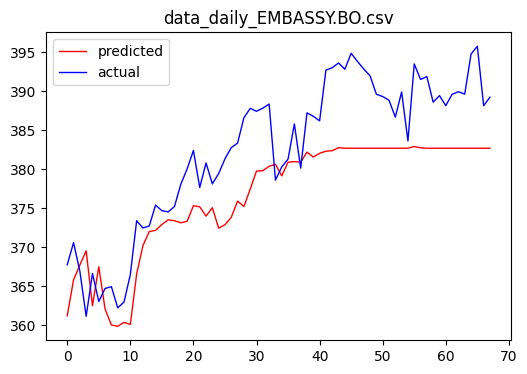

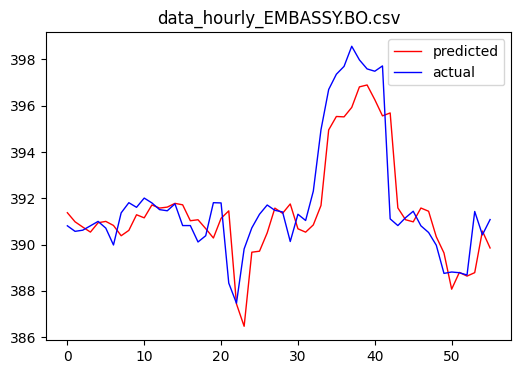

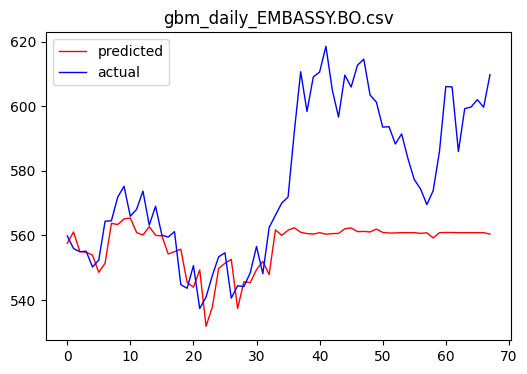

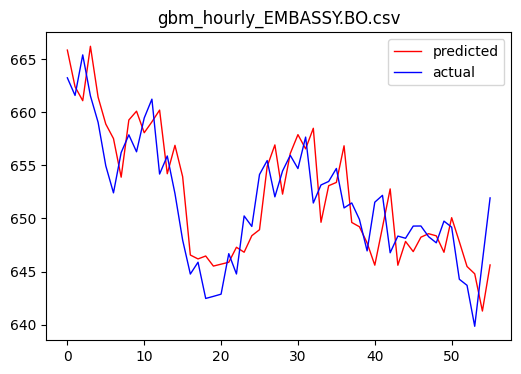

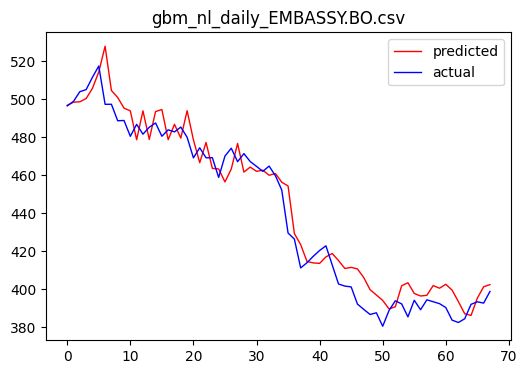

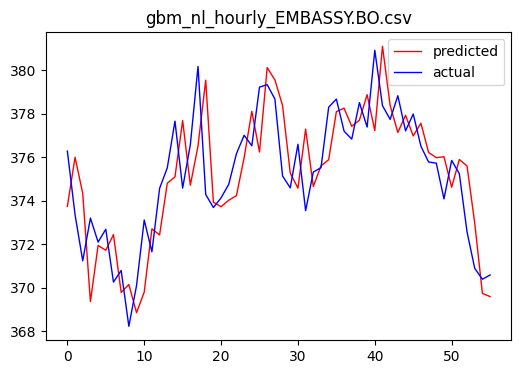

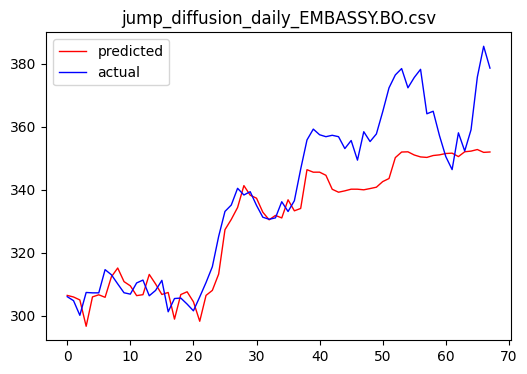

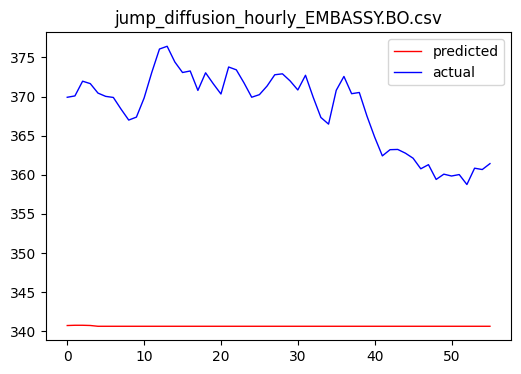

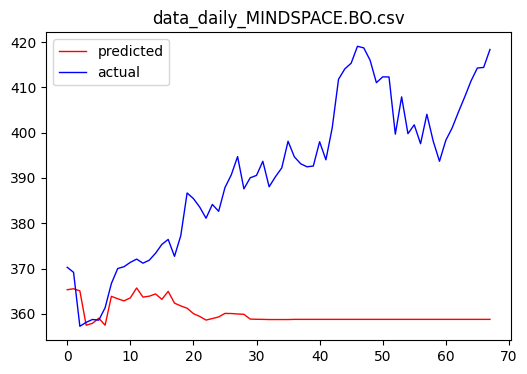

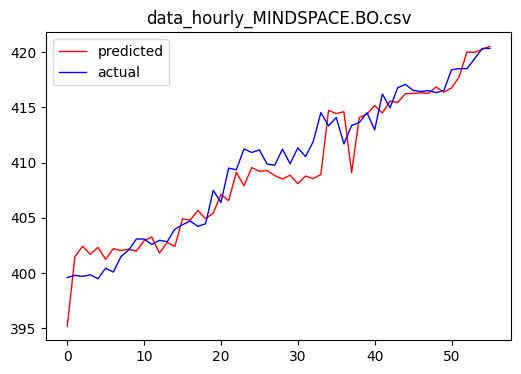

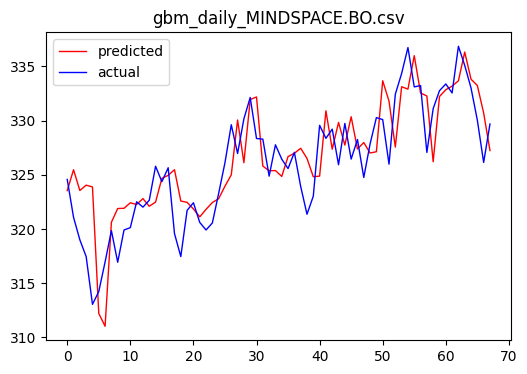

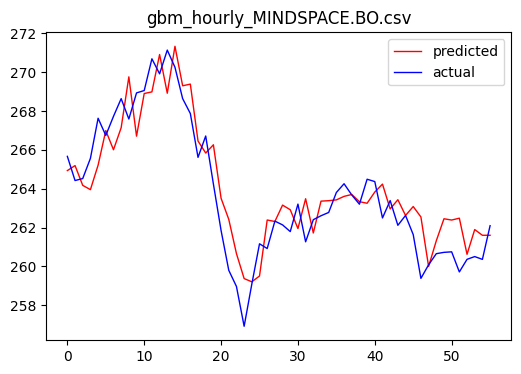

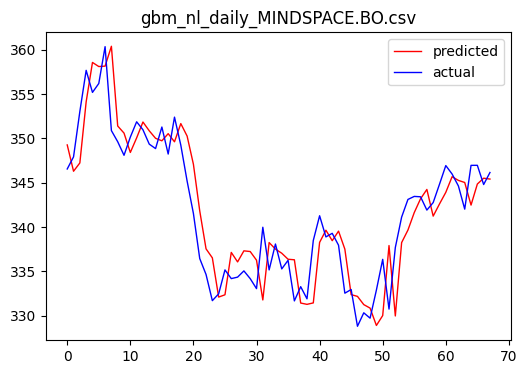

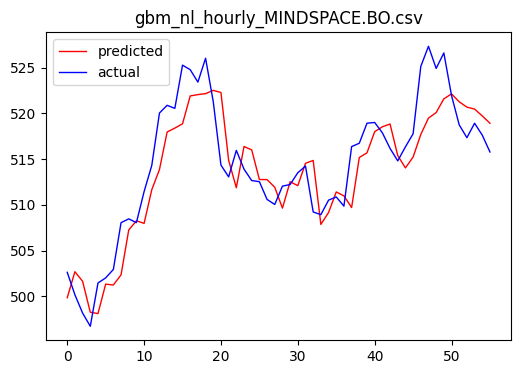

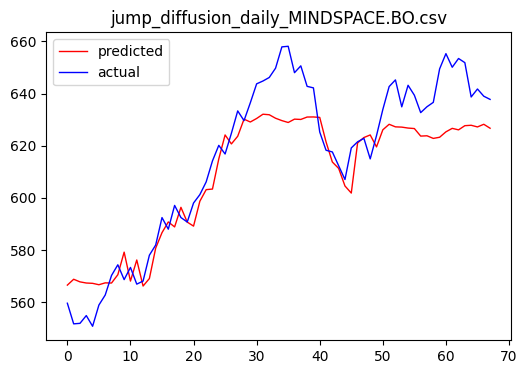

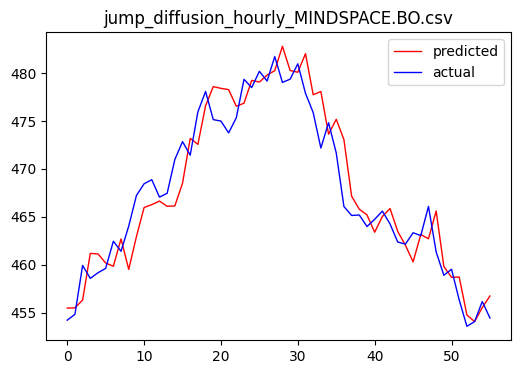

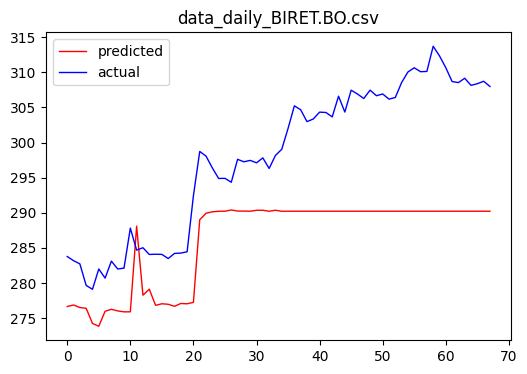

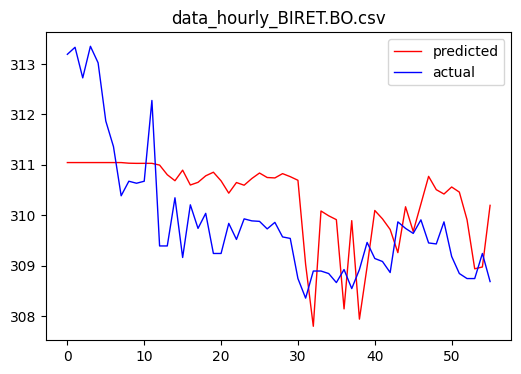

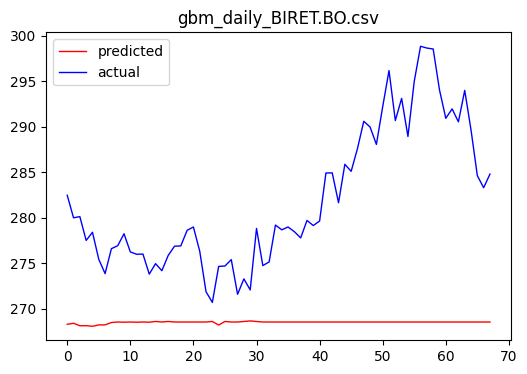

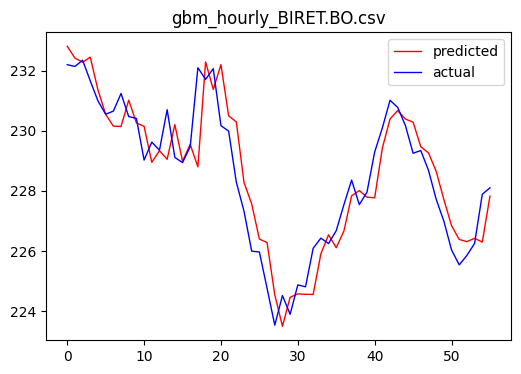

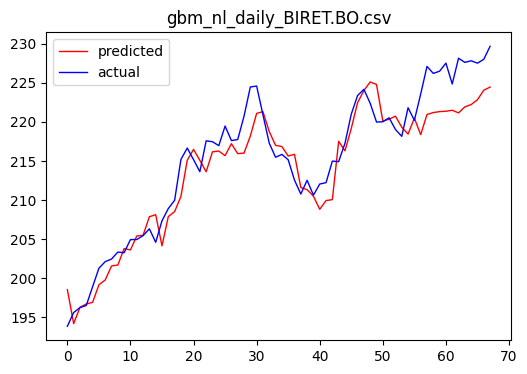

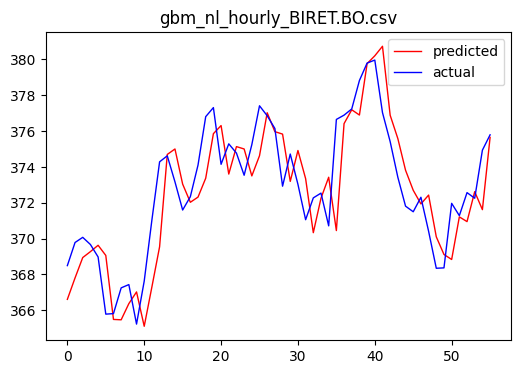

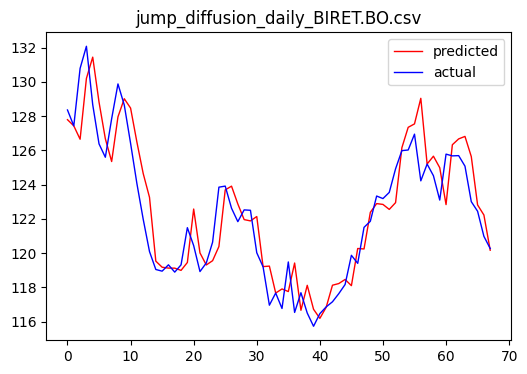

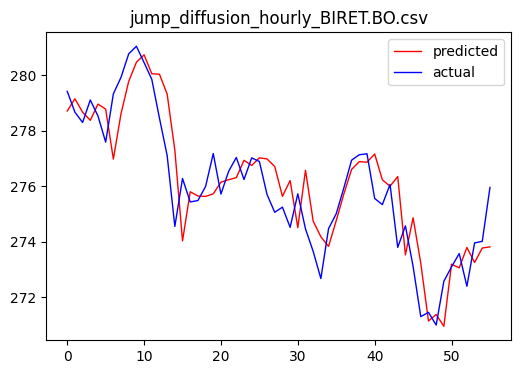

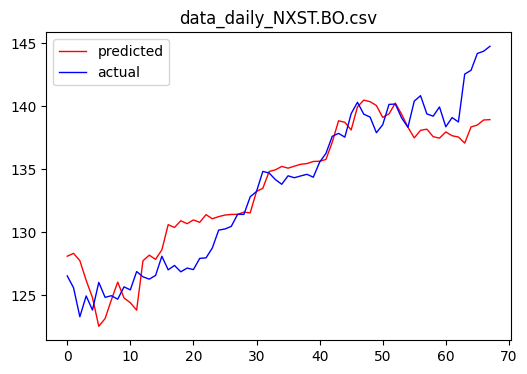

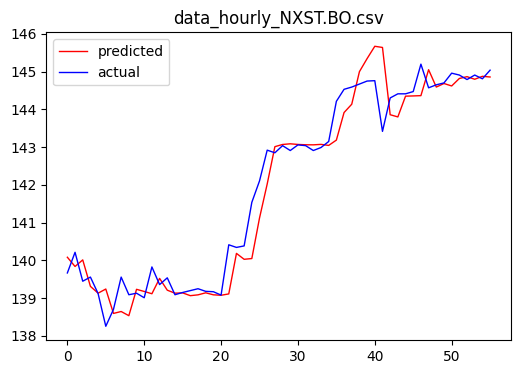

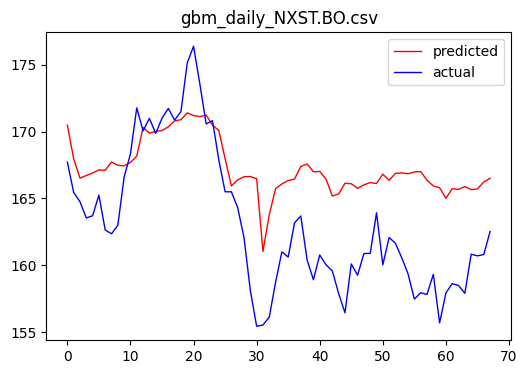

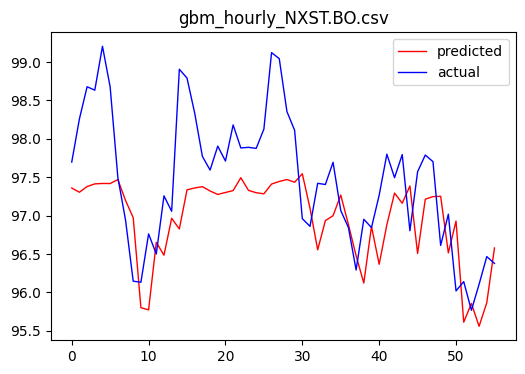

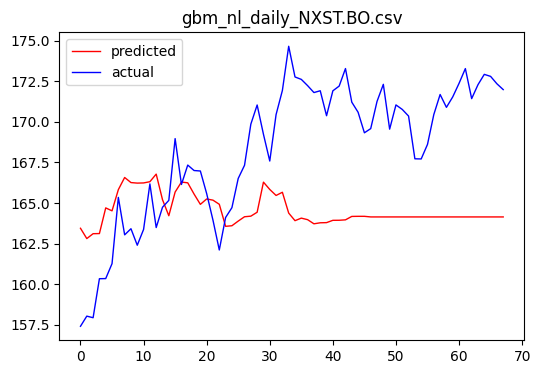

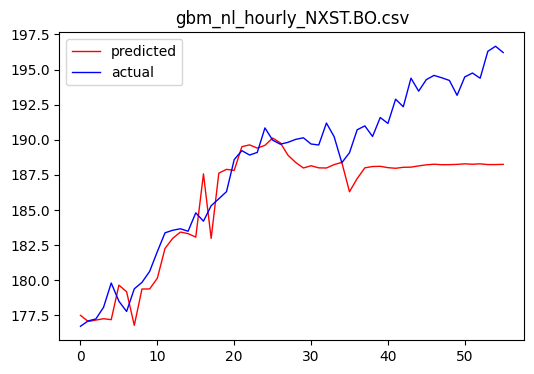

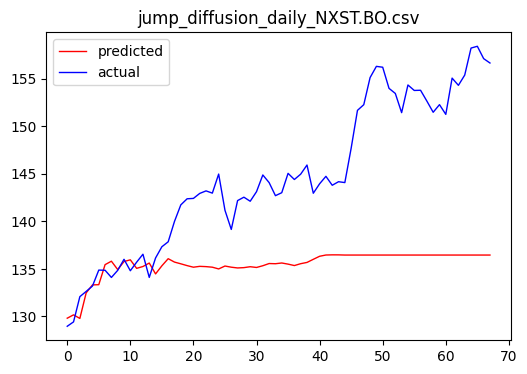

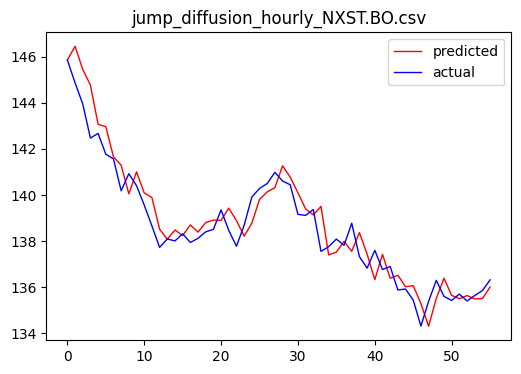

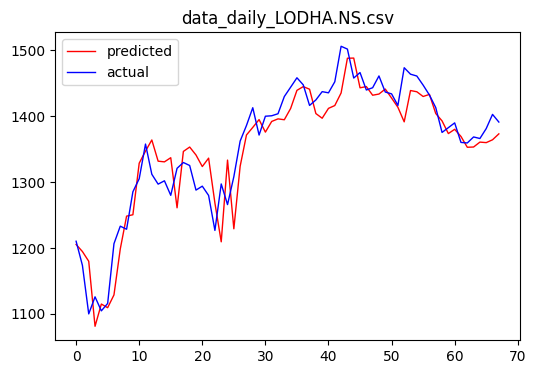

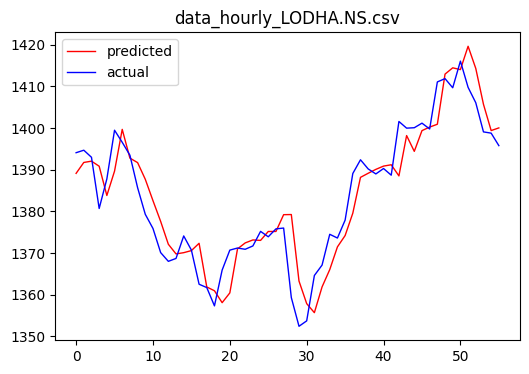

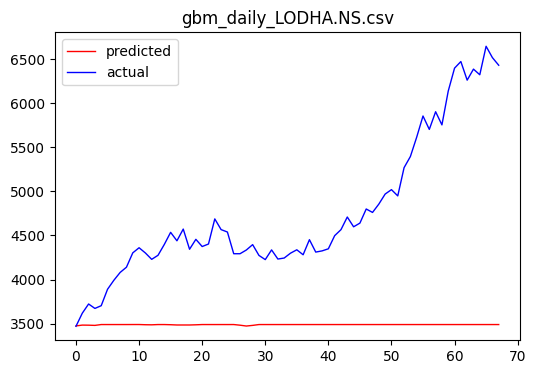

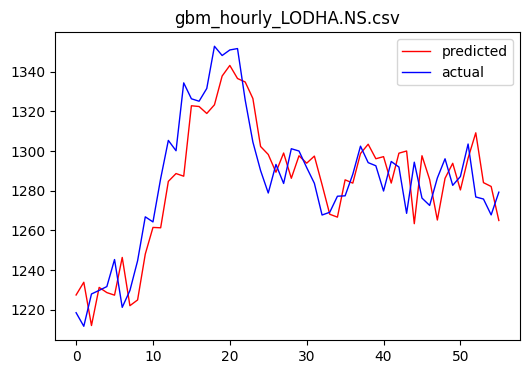

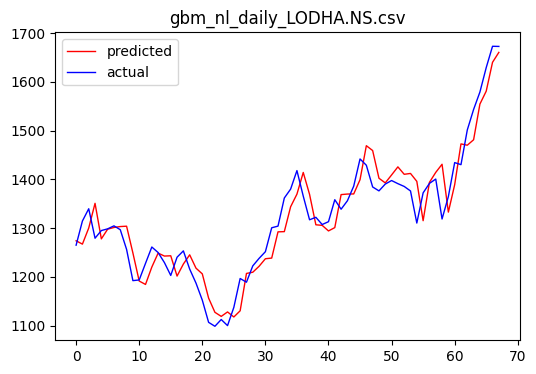

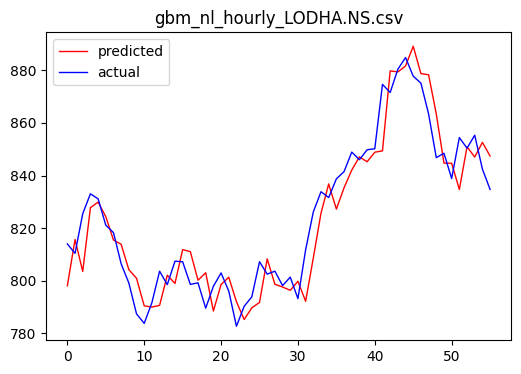

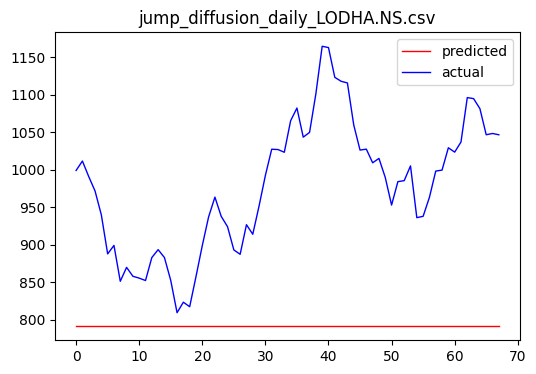

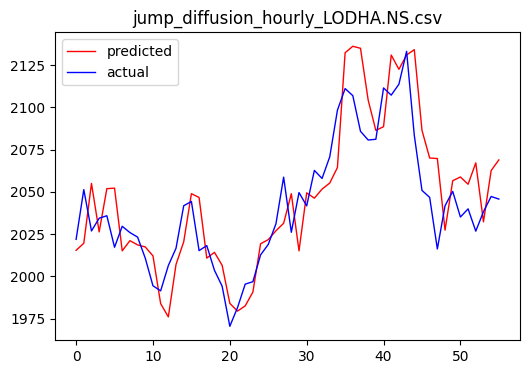

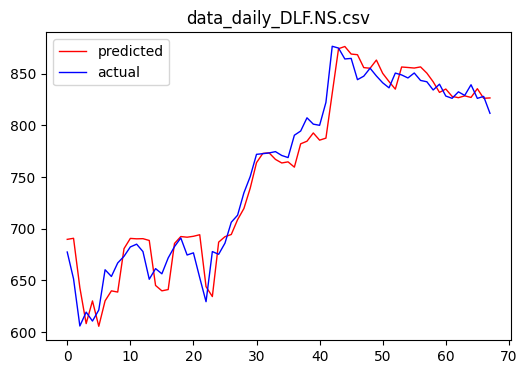

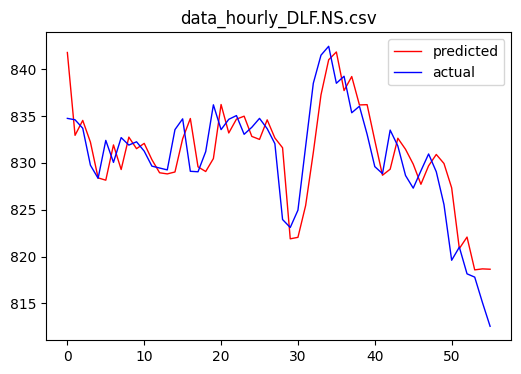

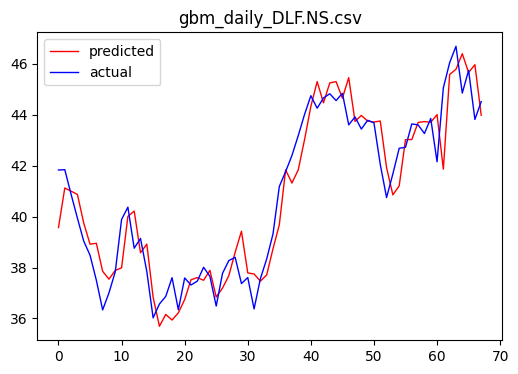

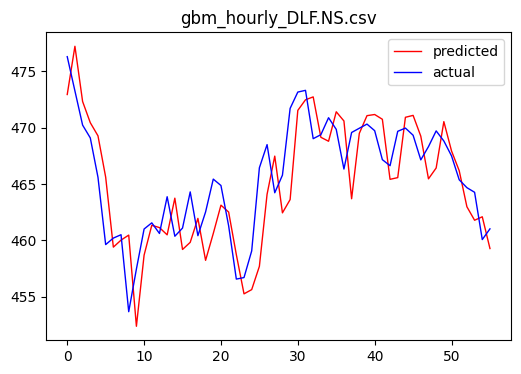

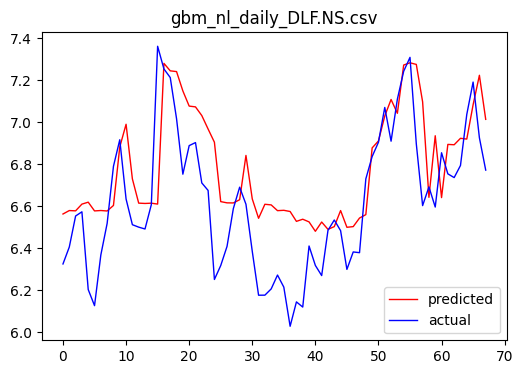

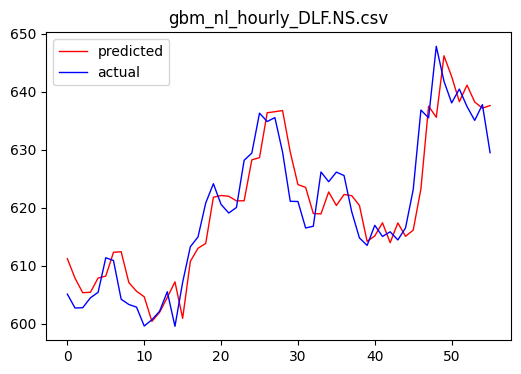

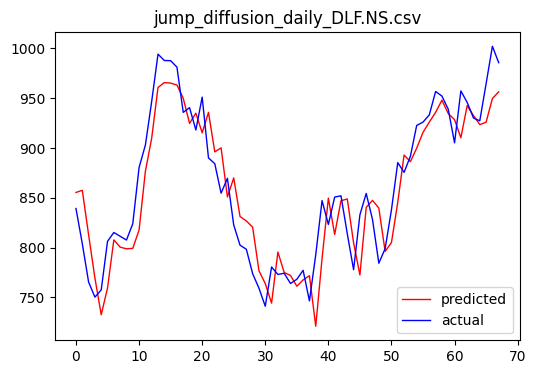

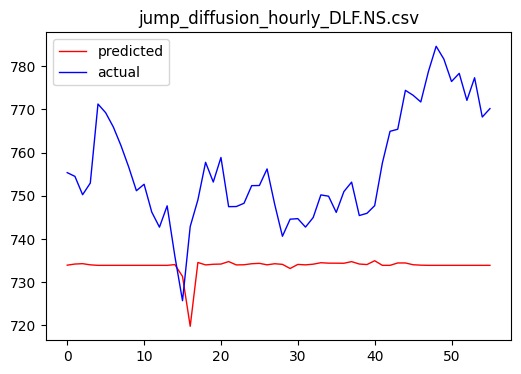

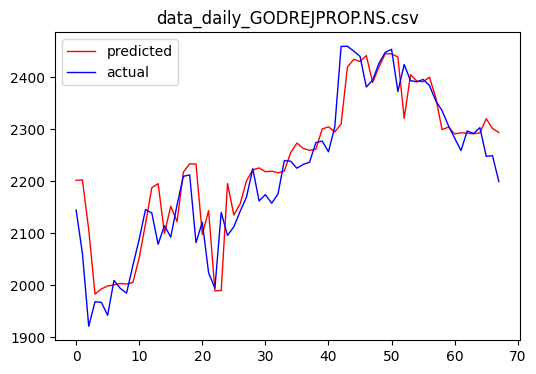

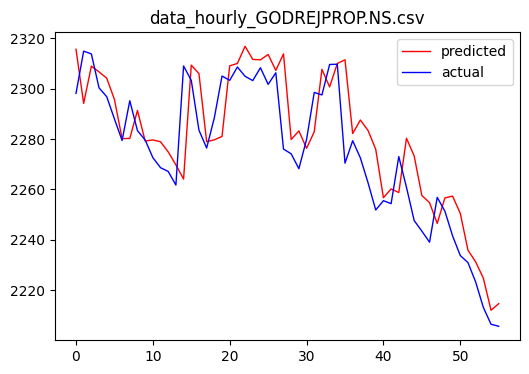

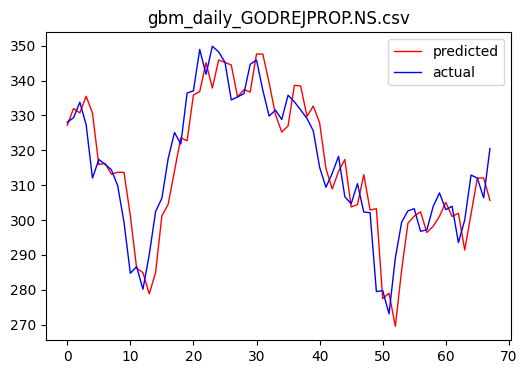

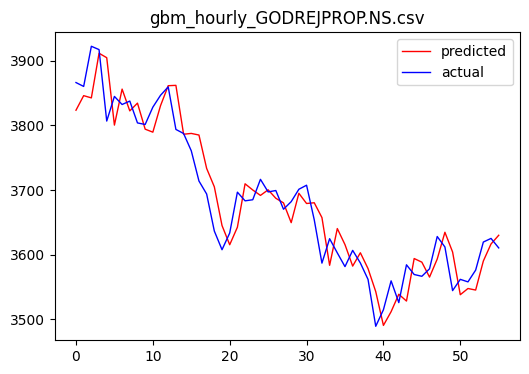

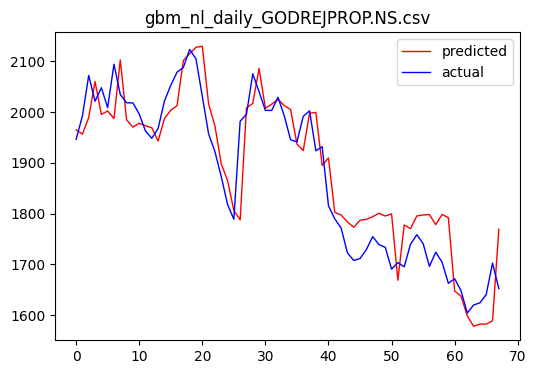

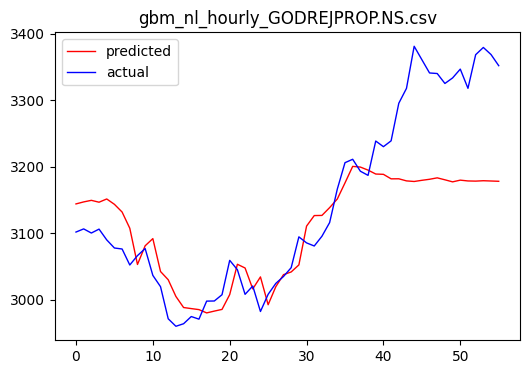

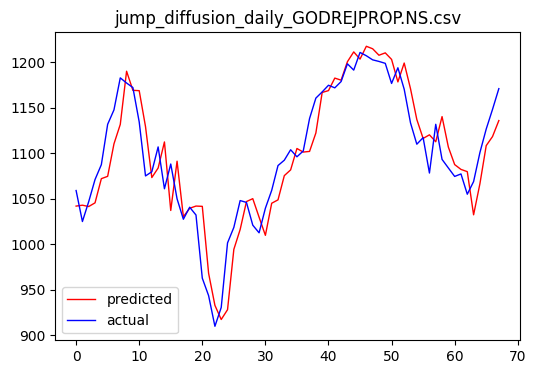

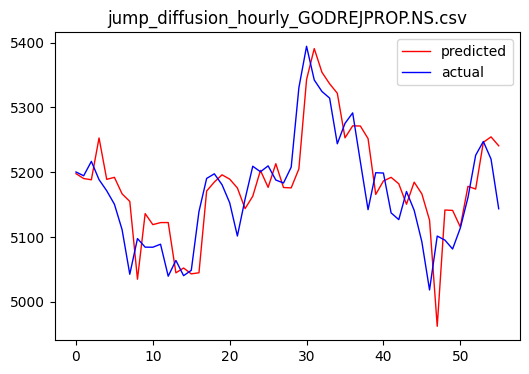

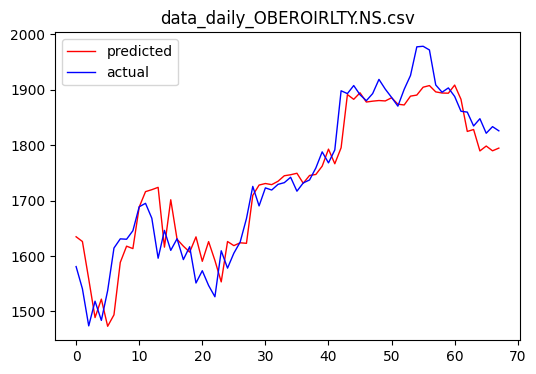

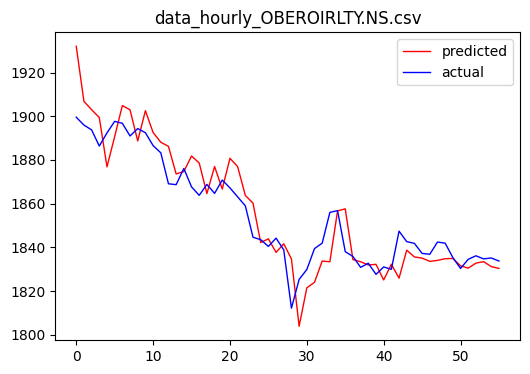

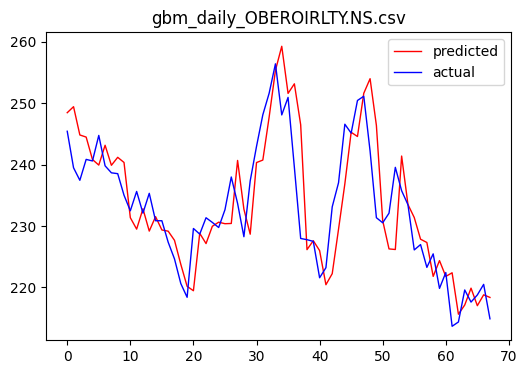

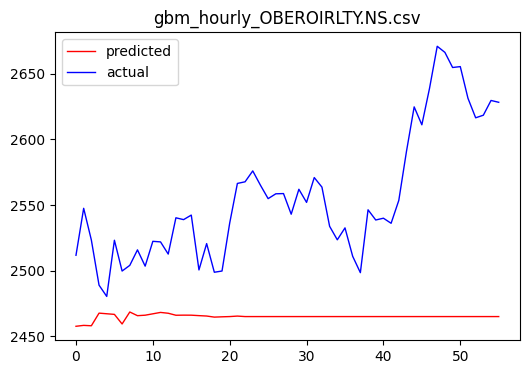

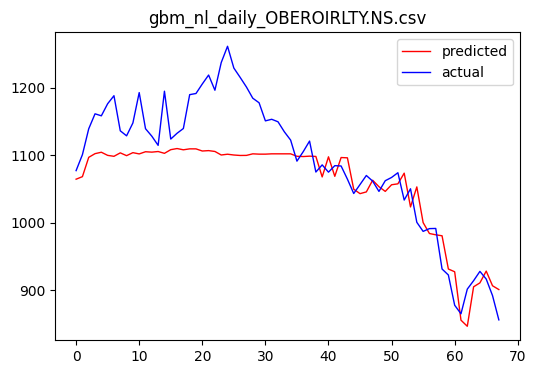

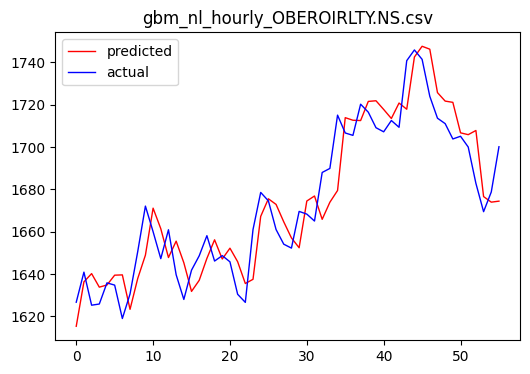

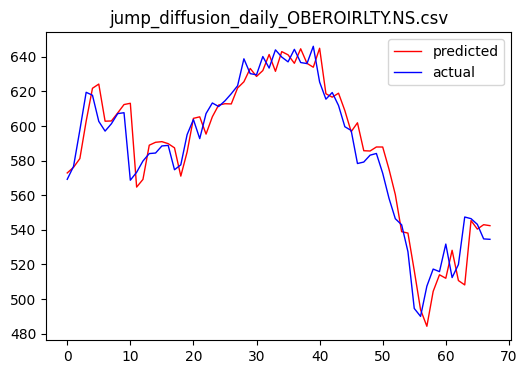

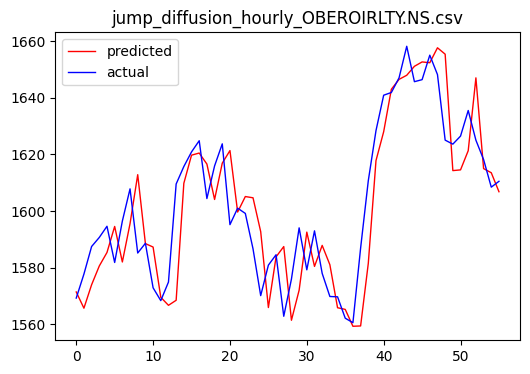

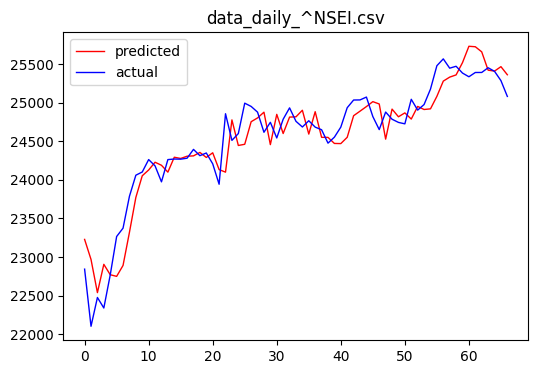

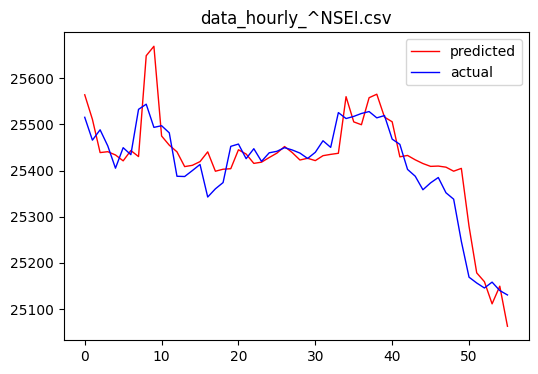

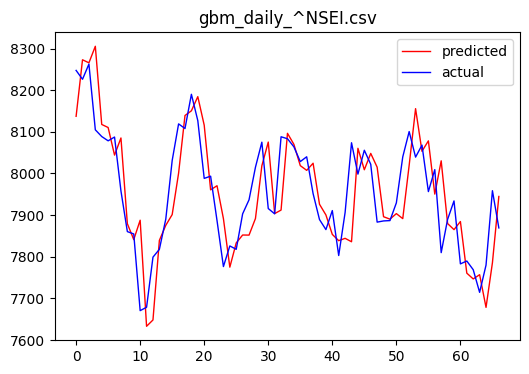

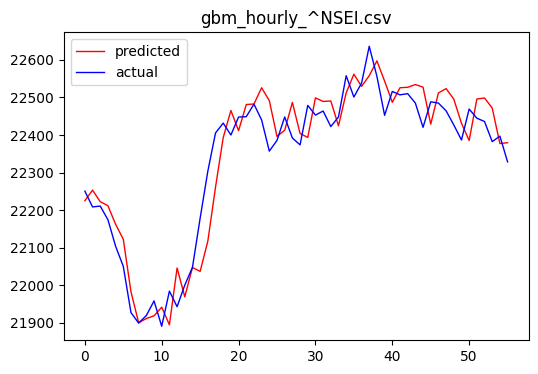

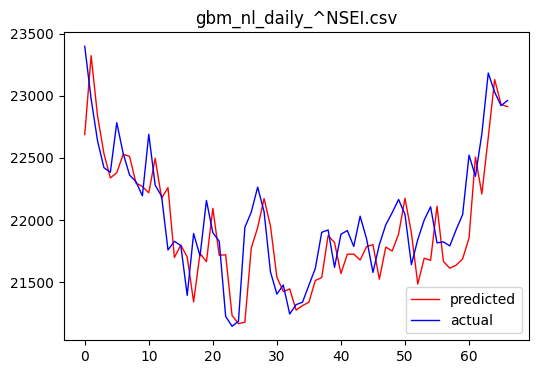

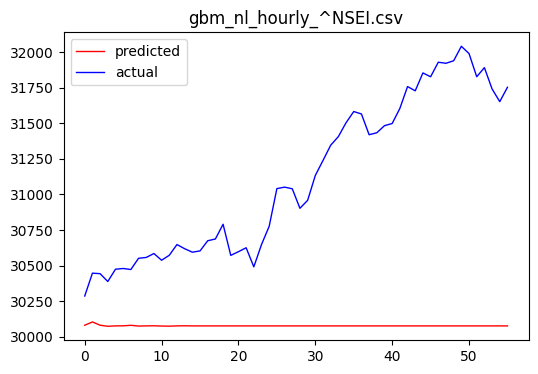

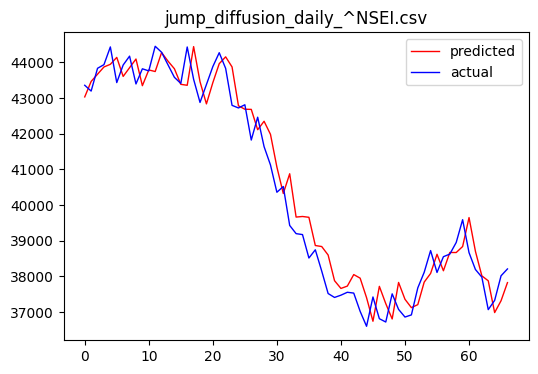

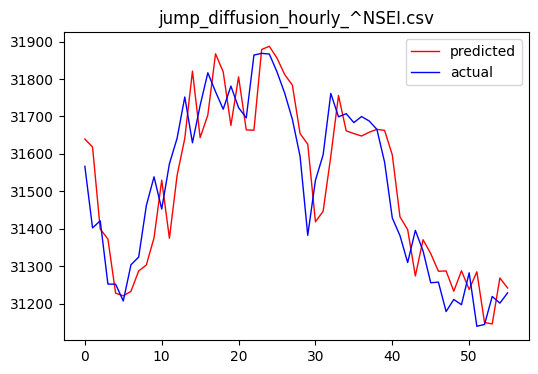

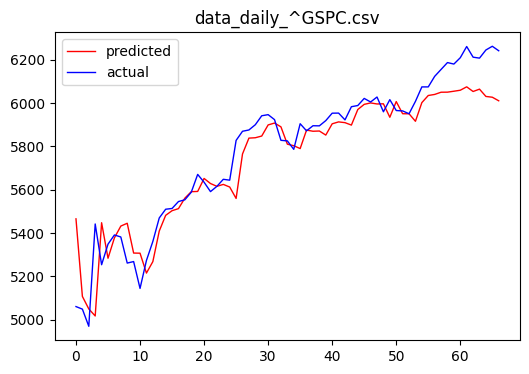

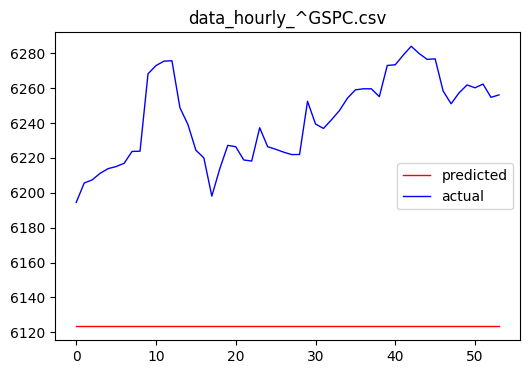

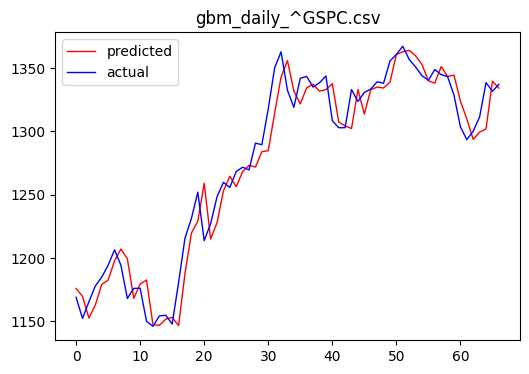

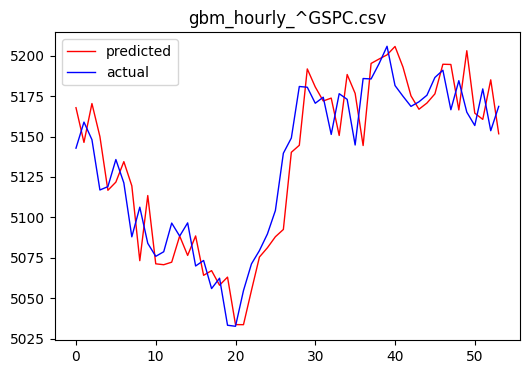

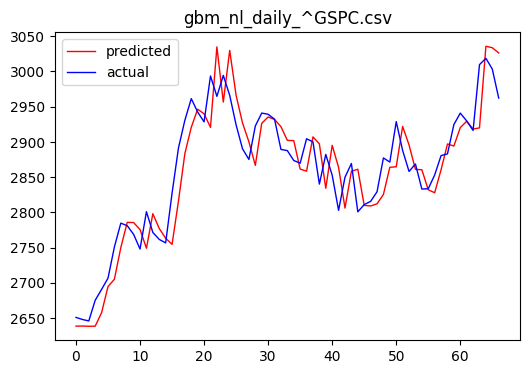

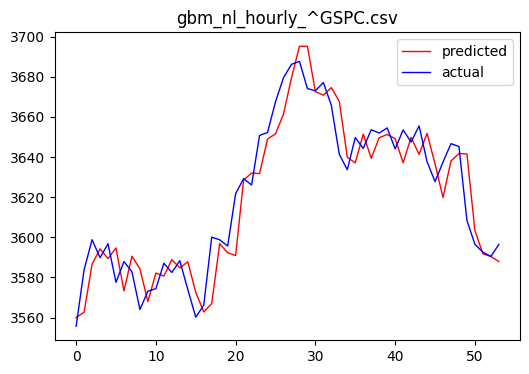

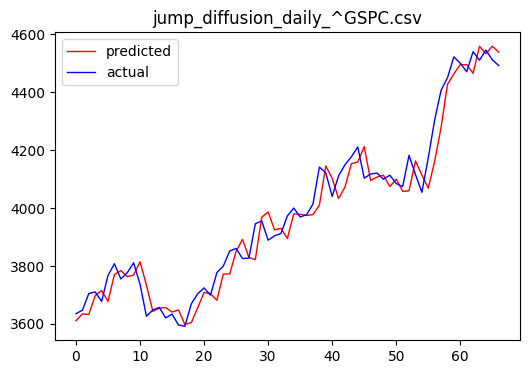

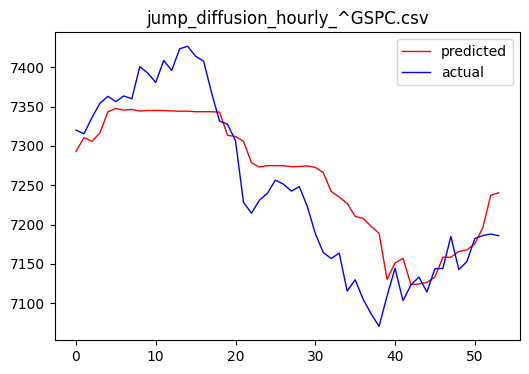

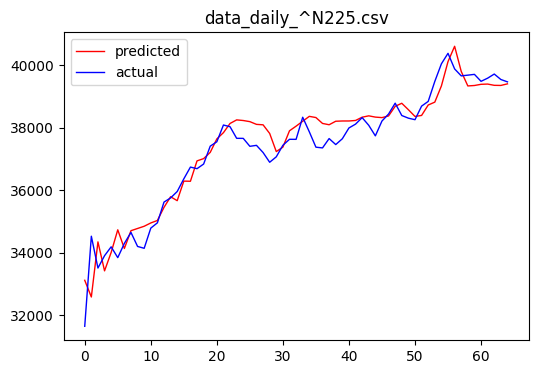

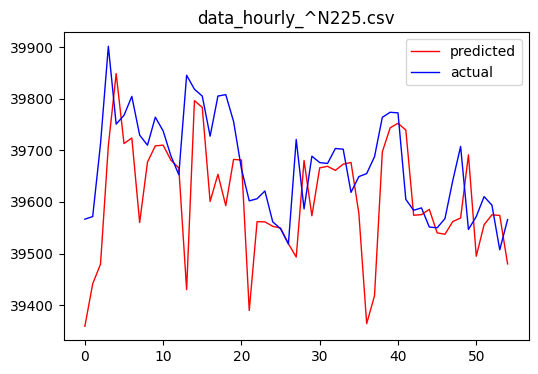

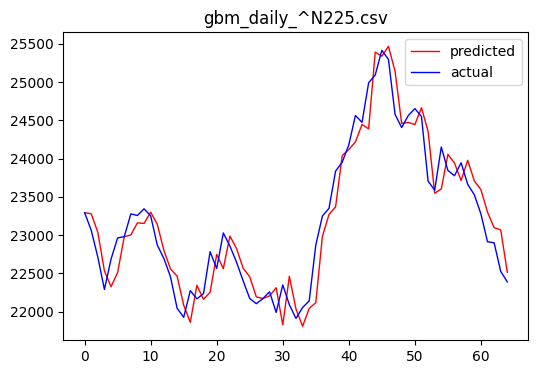

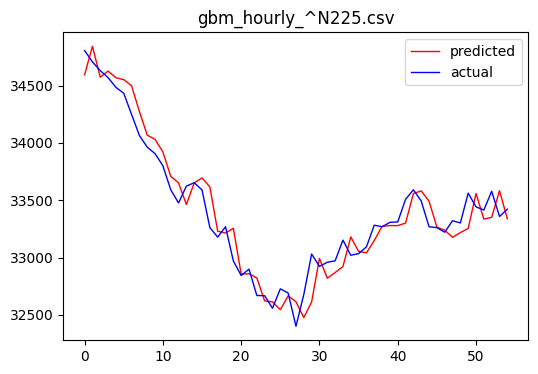

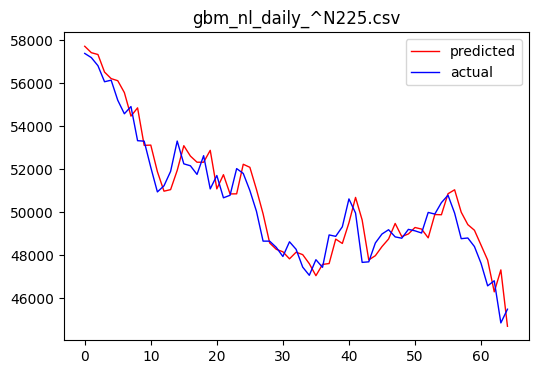

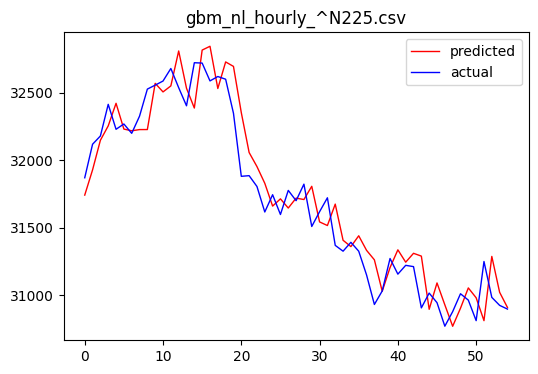

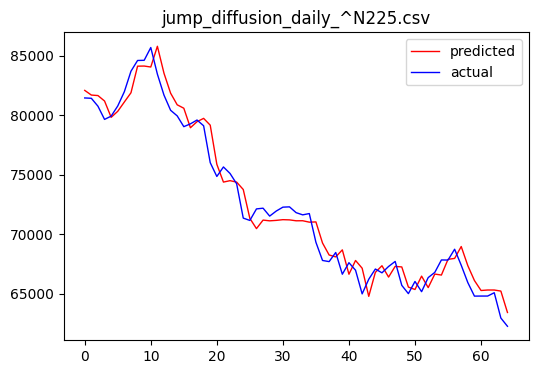

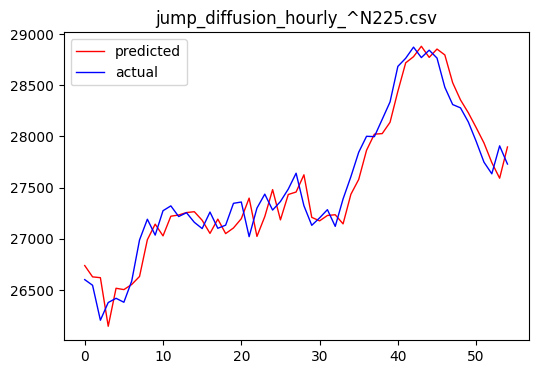

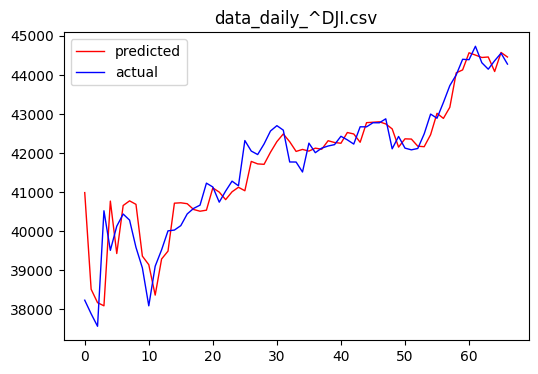

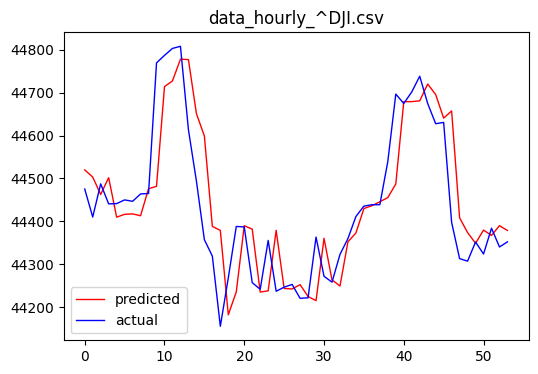

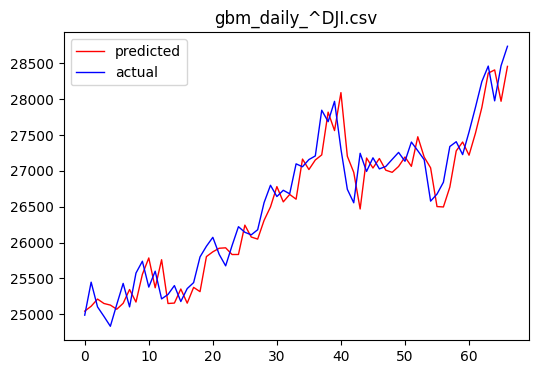

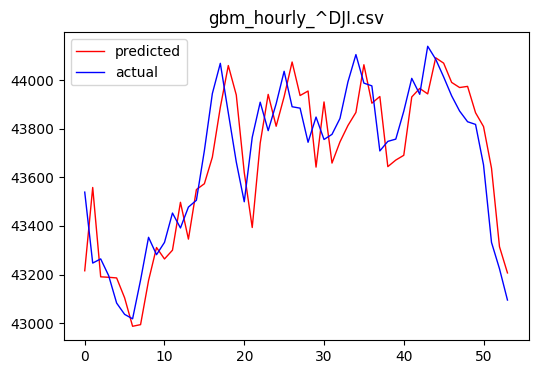

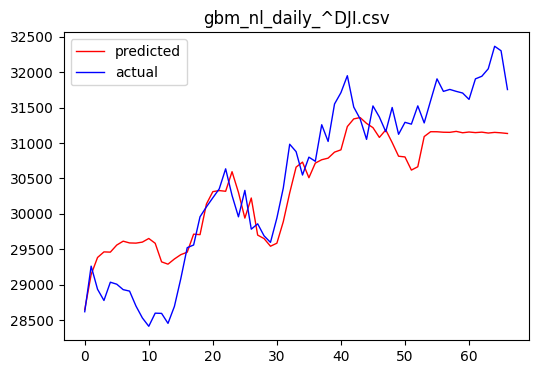

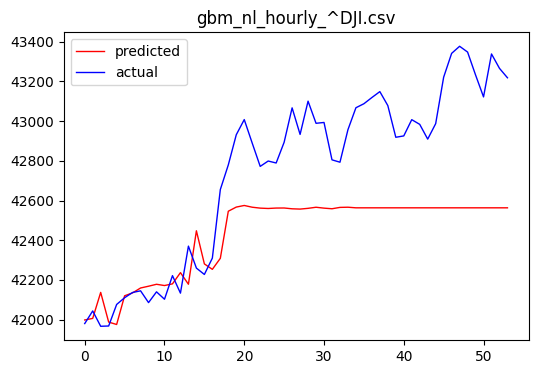

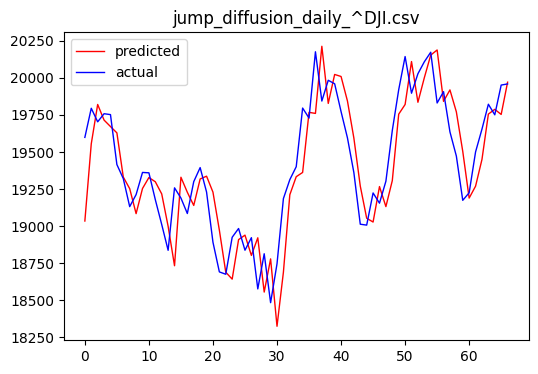

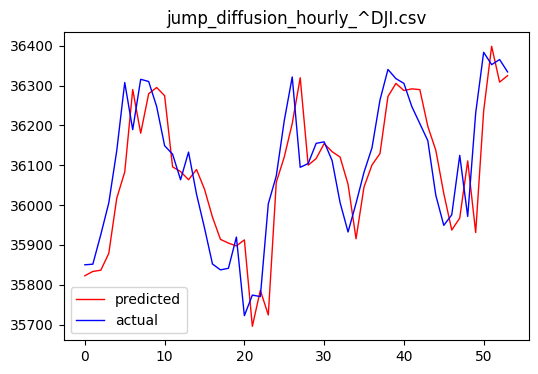

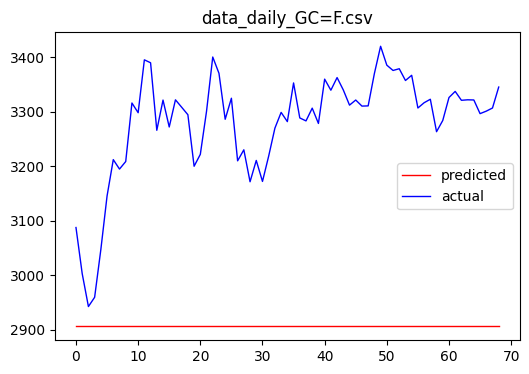

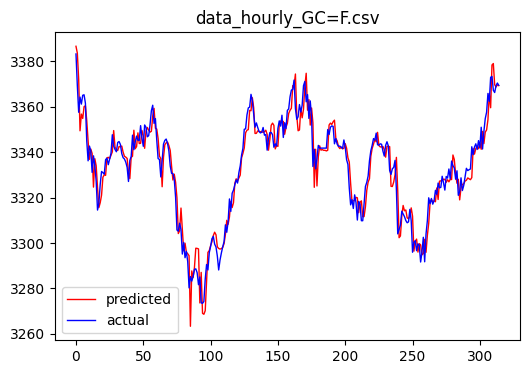

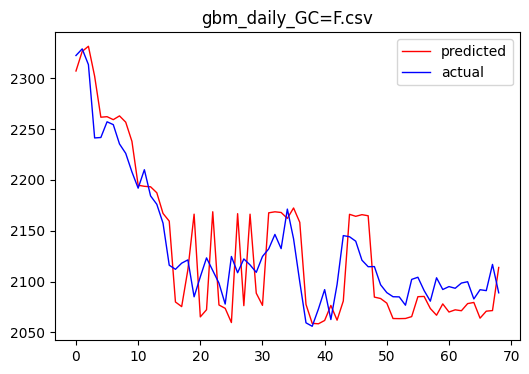

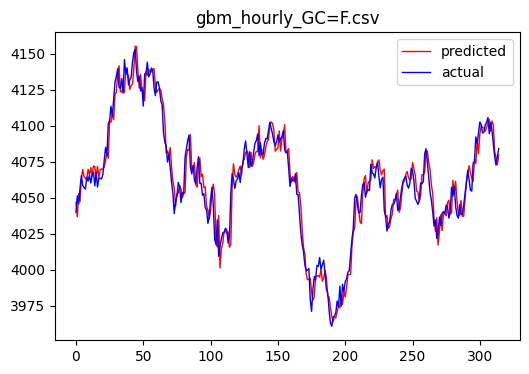

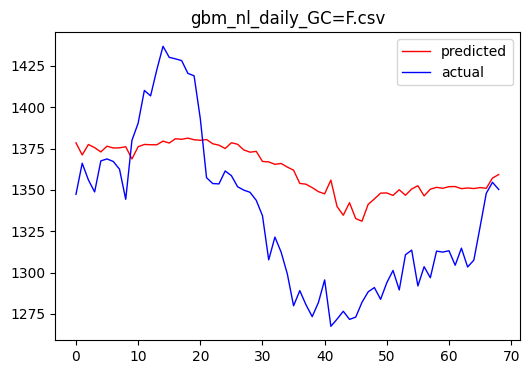

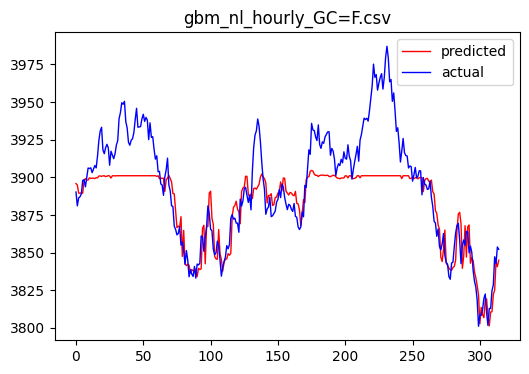

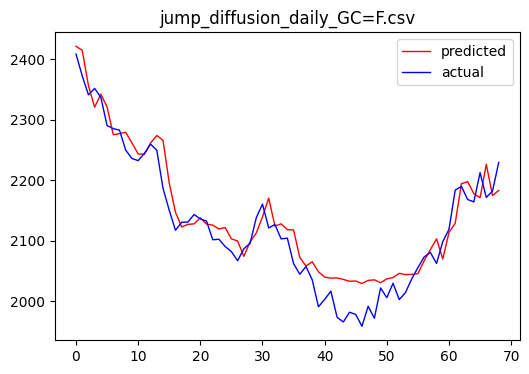

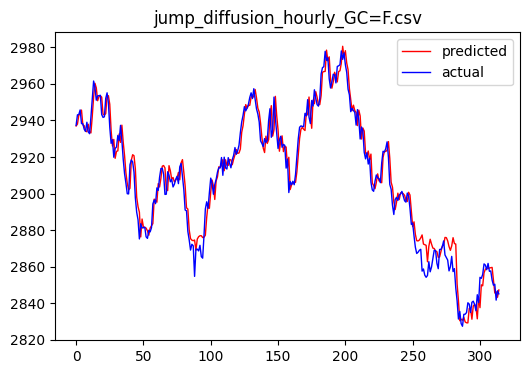

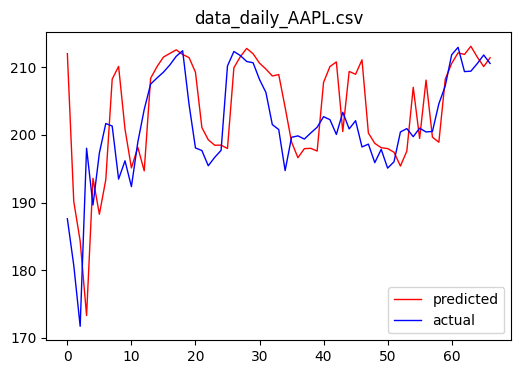

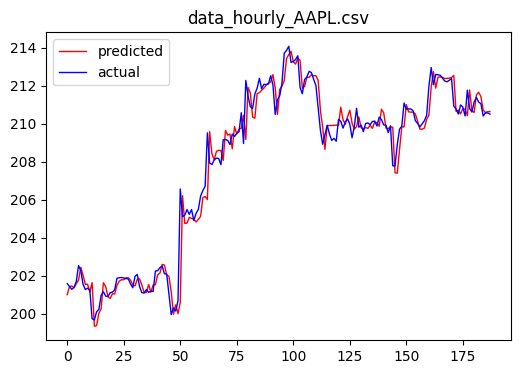

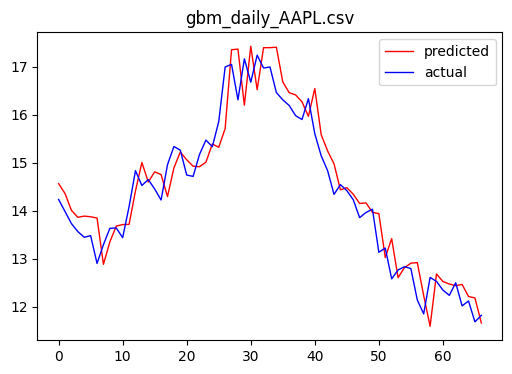

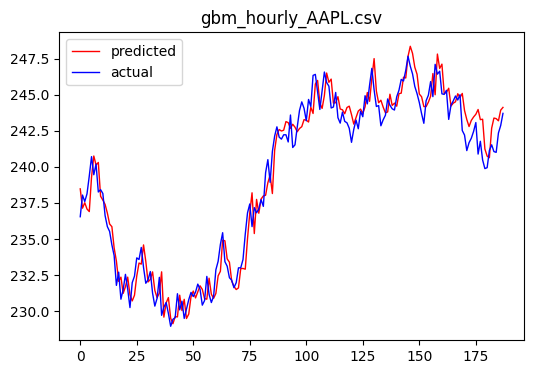

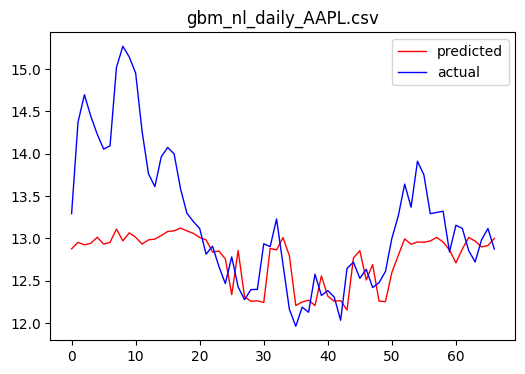

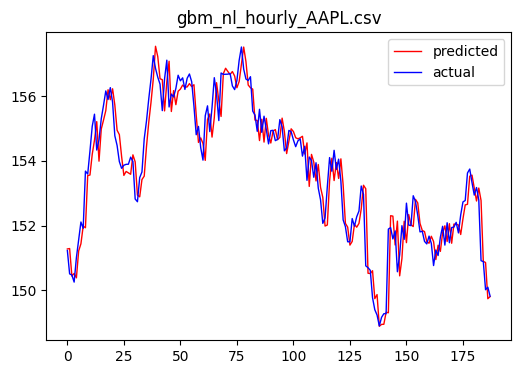

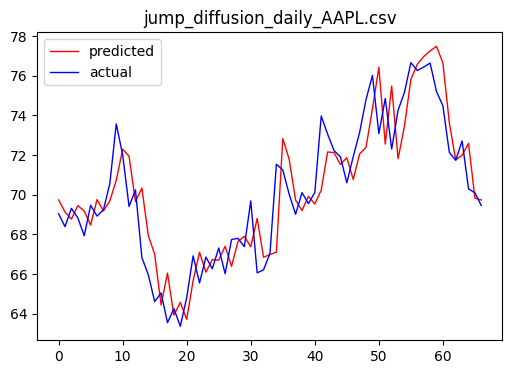

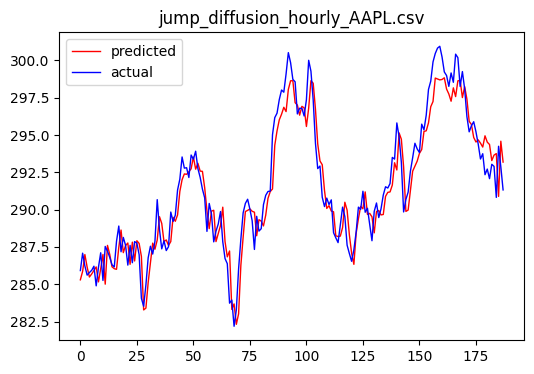

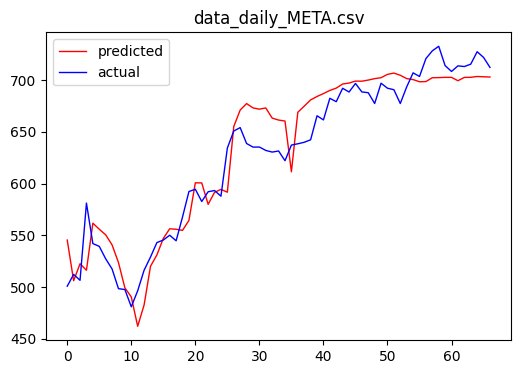

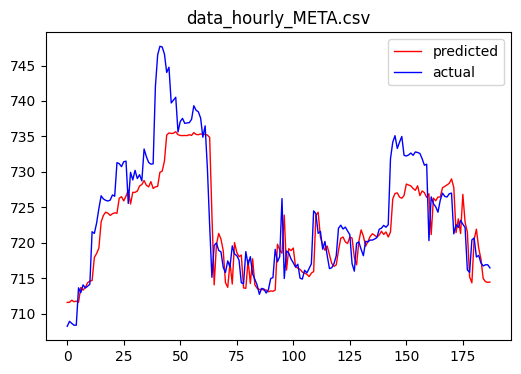

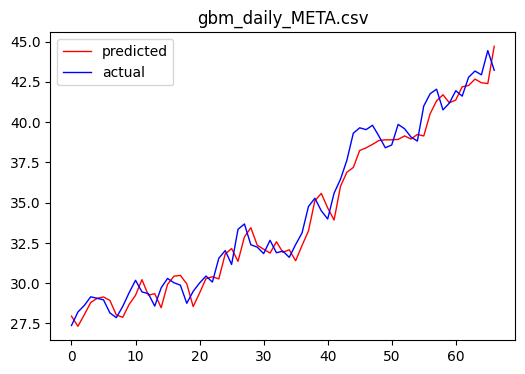

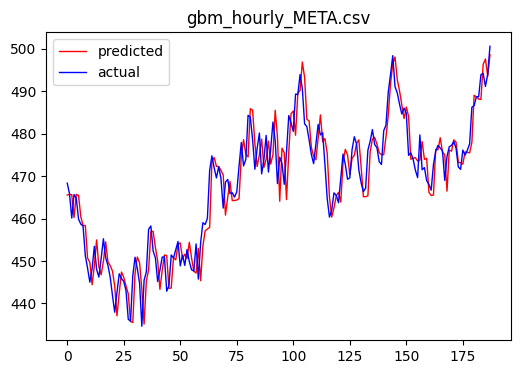

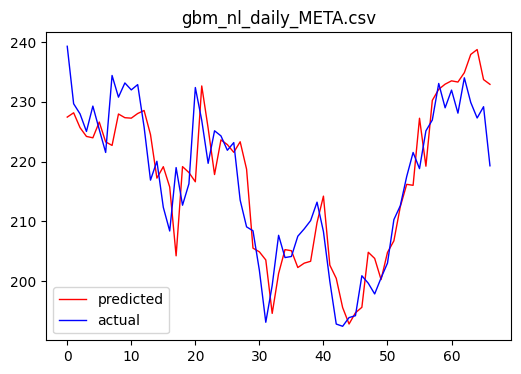

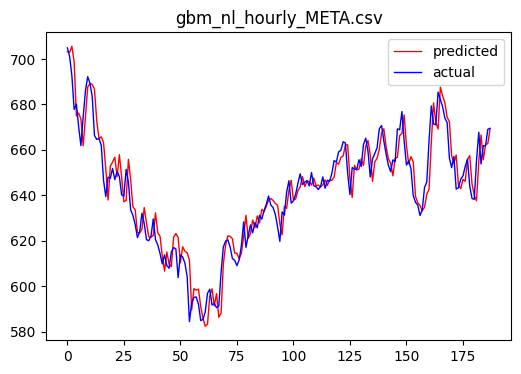

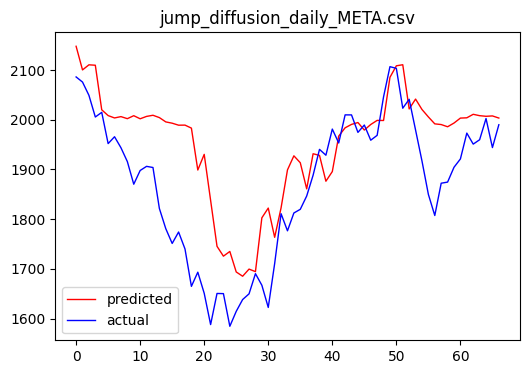

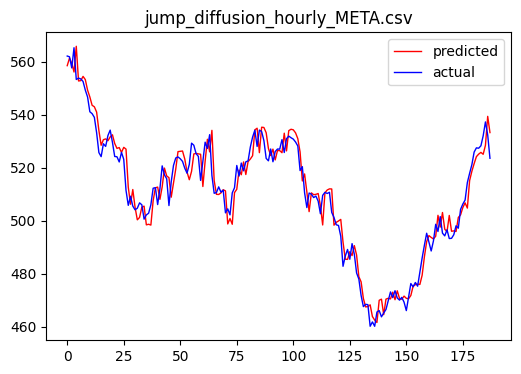

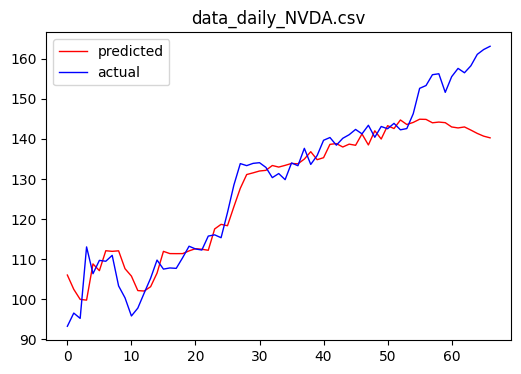

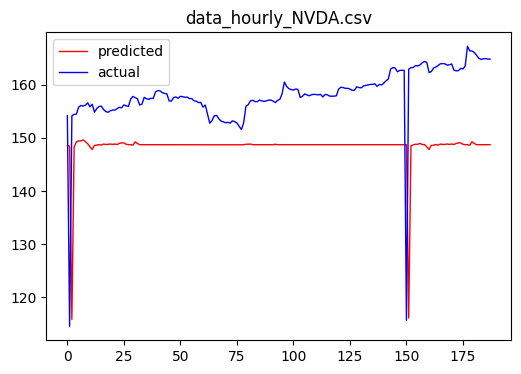

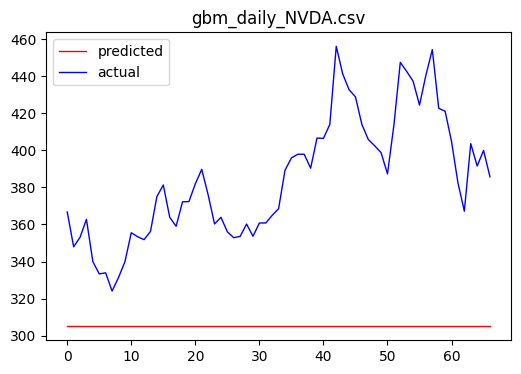

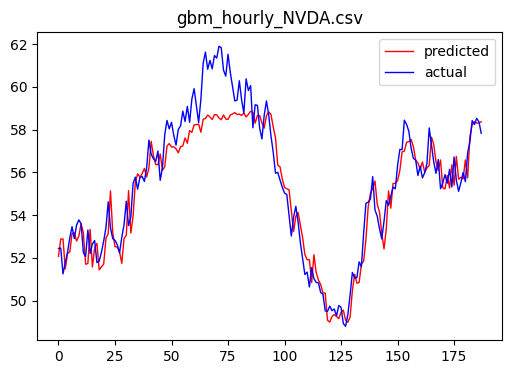

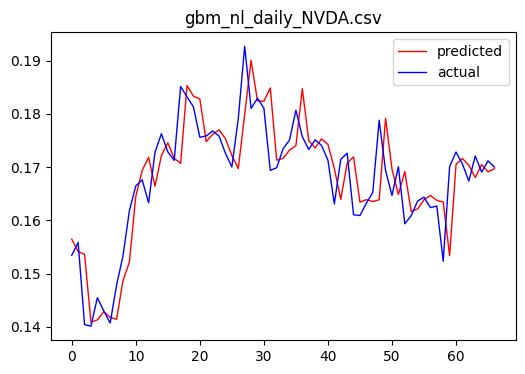

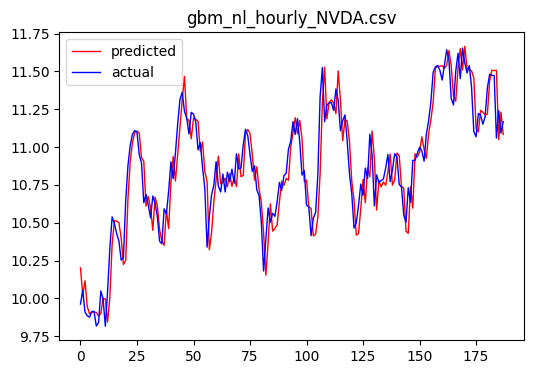

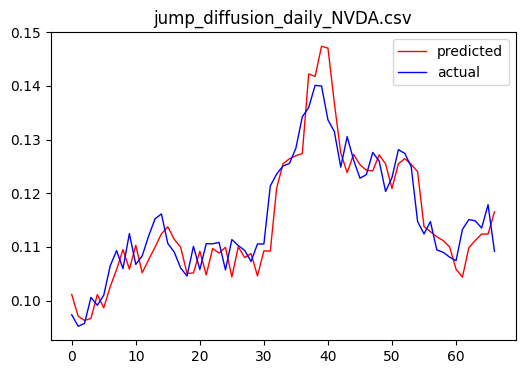

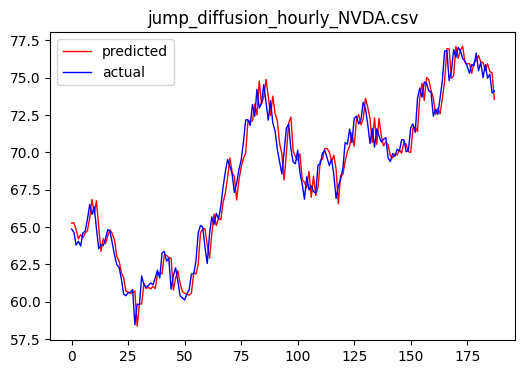

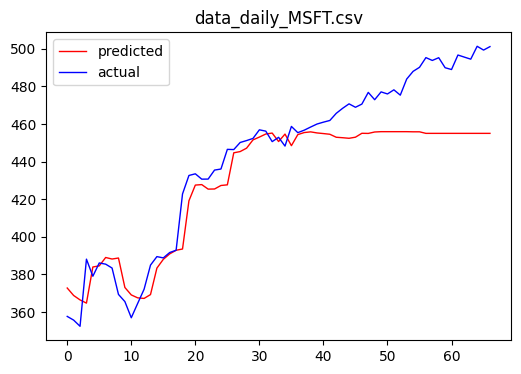

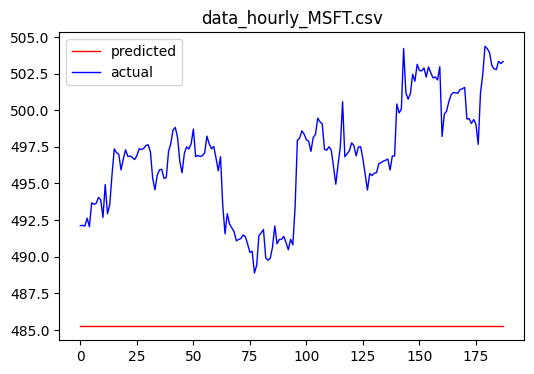

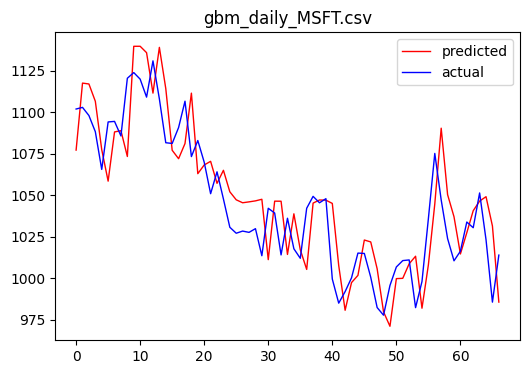

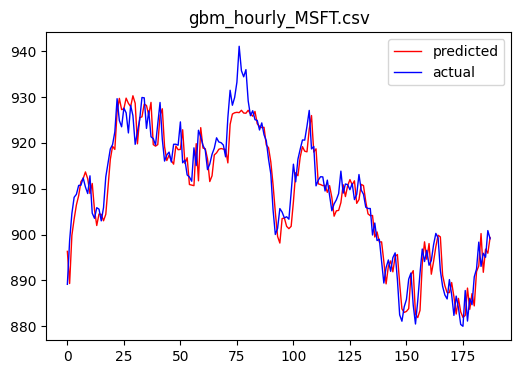

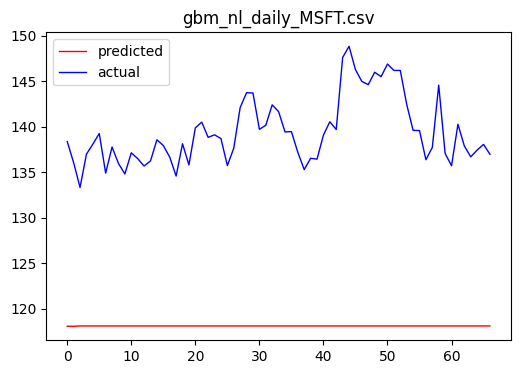

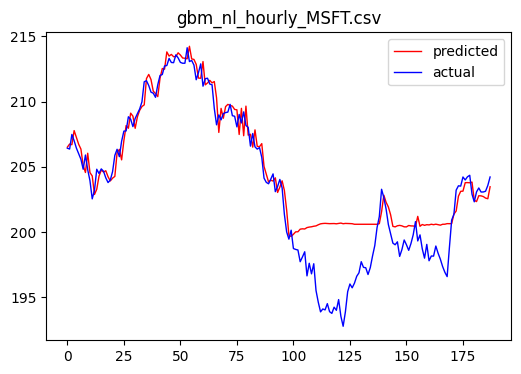

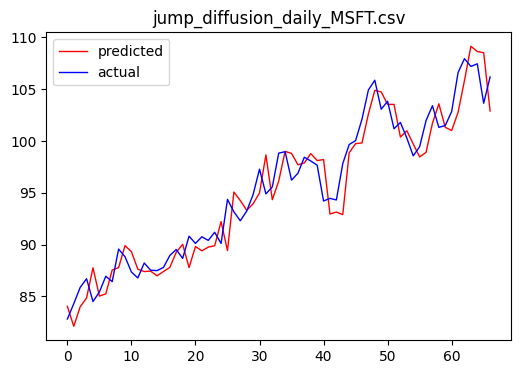

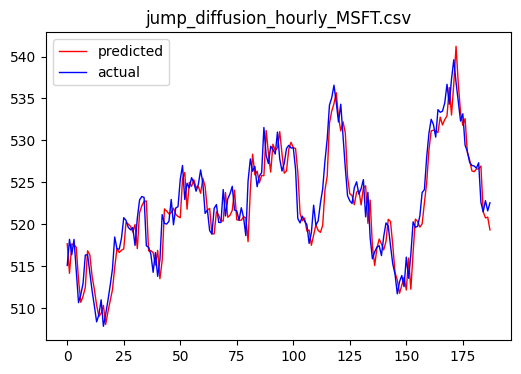

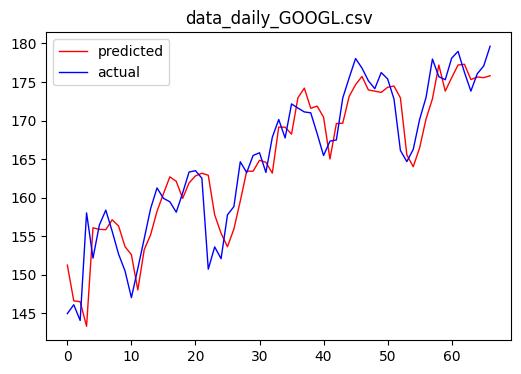

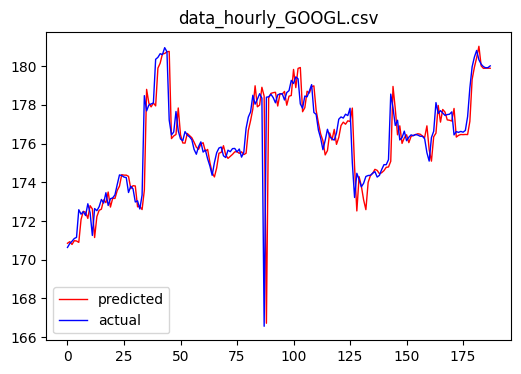

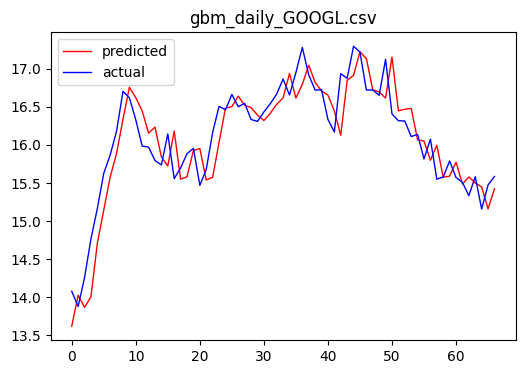

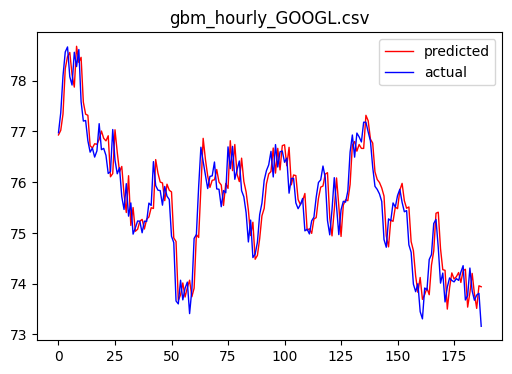

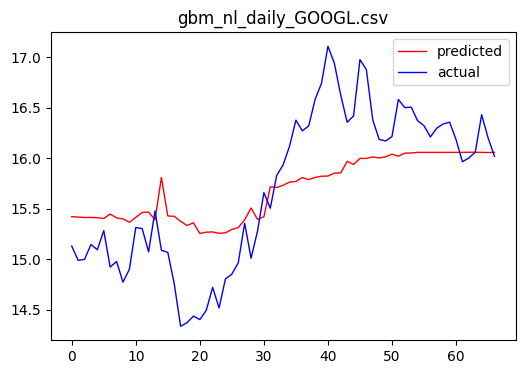

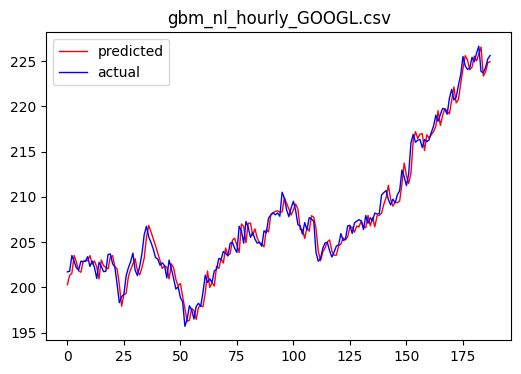

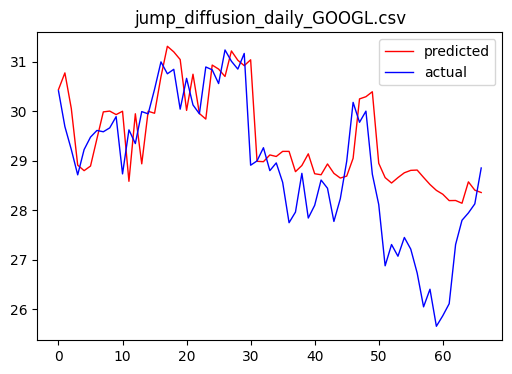

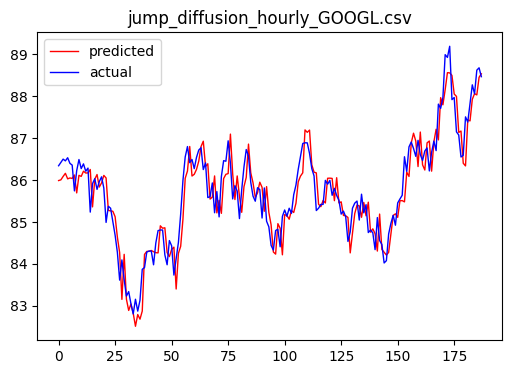

In [5]:
model = RandomForestRegressor(n_estimators=100, max_depth=10)
bulk_model_results(model, "RFRwithClose", description="RandomForestRegressor(n_estimators=100, max_depth=10) 'Close':30")